# Airbnb Price Prediction

## Objectif
Prédire le **prix pour une nuit** de différents Airbnb selon les différentes caractéristiques disponibles.

## Données
- **Train** : 22 235 annonces avec un prix connu
- **Test** :  51 881 annonces avec un prix à prédire
- Variables disponibles : ville, quartier, type de logement, infos hôte, avis, équiments disponibles...

## Étapes du projet
1. **Exploration** :            Comprendre en explorant les données les caractéristiques qui influencent le prix
2. **Préparation** :            Transformer les colonnes brutes des csv en données aisément utilisables
3. **Encodage** :               Convertir les différents textes en données numériques ppour faciliter le traitement et la prédiction
4. **Entrainement** :           LightGBM avec cross validation
5. **Analyse** :                Vérifier la cohérence du modèle

> La variable cible est `log_price` (le logarithme du prix du logement).

In [2]:
# Les différents imports nécessaires au projet
import re
import warnings
from collections import Counter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import KFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error
warnings.filterwarnings('ignore')
SEED = 13
np.random.seed(SEED)

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
pd.set_option('display.max_columns', 50)

try:
    import lightgbm as lgb
    USE_LGBM = True
    print(f"LightGBM {lgb.__version__} disponible")
except ImportError:
    USE_LGBM = False
    print("LightGBM non disponible — fallback GradientBoostingRegressor")

LightGBM 4.6.0 disponible


## 1. Chargement des données

In [3]:
train = pd.read_csv('airbnb_train.csv')
test  = pd.read_csv('airbnb_test.csv')

# On donne un nom (id) à la première colonne qui n'en avait pas auparavant.
test.rename(columns={test.columns[0]: 'id'}, inplace=True)

print(f"Train : {train.shape[0]:,} lignes par {train.shape[1]} colonnes")
print(f"Test  : {test.shape[0]:,} lignes par {test.shape[1]} colonnes")

#on peut voir que les données ne sont pas adaptées et correctement formatées
test.head(3)

Train : 22,234 lignes par 28 colonnes
Test  : 51,877 lignes par 27 colonnes


,id,property_type,room_type,amenities,accommodates,bathrooms,bed_type,cancellation_policy,cleaning_fee,city,description,first_review,host_has_profile_pic,host_identity_verified,host_response_rate,host_since,instant_bookable,last_review,latitude,longitude,name,neighbourhood,number_of_reviews,review_scores_rating,zipcode,bedrooms,beds
0,14282777,Apartment,Entire home/apt,"{""Wireless Internet"",""Air conditioning"",Kitche...",3,1.0,Real Bed,strict,True,NYC,"Beautiful, sunlit brownstone 1-bedroom in the ...",2016-06-18,t,t,NaN,2012-03-26,f,2016-07-18,40.696524,-73.991617,Beautiful brownstone 1-bedroom,Brooklyn Heights,2,100.0,11201,1.0,1.0
1,17029381,Apartment,Entire home/apt,"{""Wireless Internet"",""Air conditioning"",Kitche...",7,1.0,Real Bed,strict,True,NYC,Enjoy travelling during your stay in Manhattan...,2017-08-05,t,f,100%,2017-06-19,t,2017-09-23,40.766115,-73.989040,Superb 3BR Apt Located Near Times Square,Hell's Kitchen,6,93.0,10019,3.0,3.0
2,7824740,Apartment,Entire home/apt,"{TV,""Cable TV"",""Wireless Internet"",""Air condit...",5,1.0,Real Bed,moderate,True,NYC,The Oasis comes complete with a full backyard ...,2017-04-30,t,t,100%,2016-10-25,t,2017-09-14,40.808110,-73.943756,The Garden Oasis,Harlem,10,92.0,10027,1.0,3.0


## 2. Exploration des données (EDA)

In [4]:
# Affiche les colonnes avec des valeurs manquantes, triées par fréquence (les Nan et chaines vides comptent comme valeures manquantes)
def missing_report(df, name):
    manquants = (df.isnull() | (df == '')).sum()
    manquants = manquants[manquants > 0].sort_values(ascending=False)
    pourcentage = (manquants / len(df) * 100).round(1)
    rapport = pd.DataFrame({
        'manquants': manquants,
        '%': pourcentage,
    })
    print(f"\nValeures manquantes par données dans {name} ")
    print(rapport.to_string())


missing_report(train, 'Train')


Valeures manquantes par données dans Train 
                        manquants     %
host_response_rate           5475  24.6
review_scores_rating         4978  22.4
first_review                 4725  21.3
last_review                  4716  21.2
neighbourhood                2086   9.4
zipcode                       303   1.4
host_has_profile_pic           56   0.3
host_identity_verified         56   0.3
host_since                     56   0.3
bathrooms                      51   0.2
beds                           35   0.2
bedrooms                       26   0.1


### Observations et Analyse des valeurs manquantes

Certaines colonnes ont d'important problèmes de valeures manquantes : 
- `host_response_rate` car une forte part des hotes ne remplissent pas ce champ
- `review_scores_rating`, `first_review`, `last_review` sont vides pour toute les nouvelles annonces et ont donc 40% de valeurs manquantes.

**Solution** on crée une colonne pour indiquer si la date de la premiere review est nulle car l'information va être utile et on va remplacer les valeures numériques manquantes par la médiane.

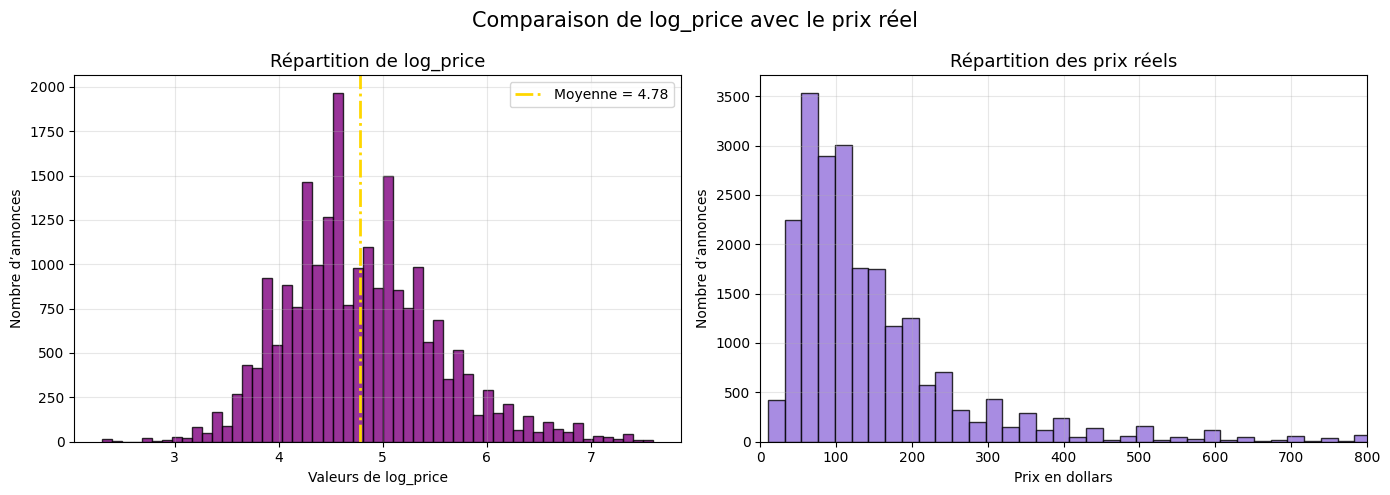

minimum = 2.30 | maximum = 7.60 | moyenne = 4.78 | écart-type = 0.72


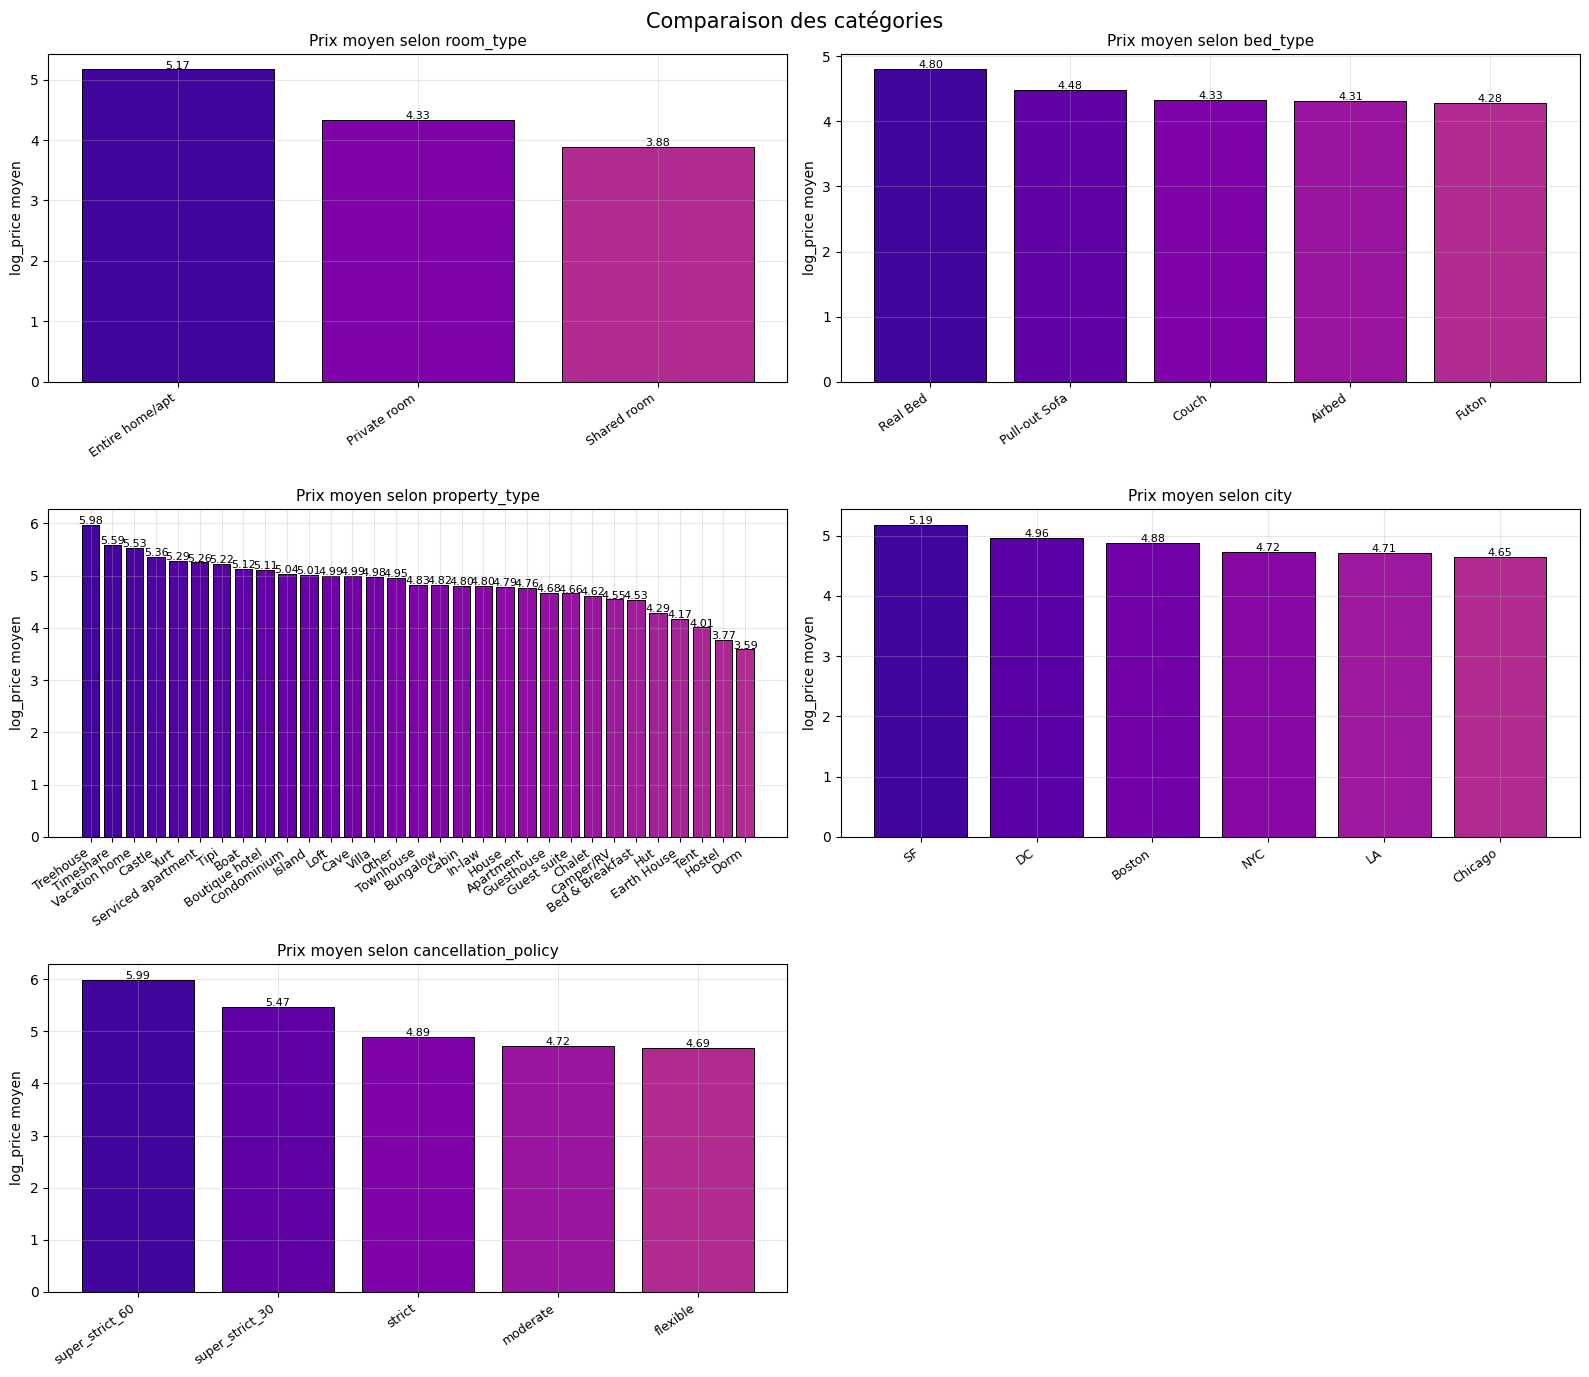

In [5]:
# On visualise log_price et price pour pouvoir les comparer et comprendre le choix de variable cible
figure, graphique = plt.subplots(1, 2, figsize=(14, 5))

graphique[0].hist(
    train['log_price'],
    bins=55,
    color='purple',
    edgecolor='black',
    alpha=0.8
)
graphique[0].axvline(
    train['log_price'].mean(),
    color='gold',
    linestyle='-.',
    linewidth=2,
    label=f"Moyenne = {train['log_price'].mean():.2f}"
)
graphique[0].set_title('Répartition de log_price', fontsize=13)
graphique[0].set_xlabel('Valeurs de log_price')
graphique[0].set_ylabel('Nombre d’annonces')
graphique[0].legend()

graphique[1].hist(
    np.exp(train['log_price']),
    bins=90,
    color='mediumpurple',
    edgecolor='black',
    alpha=0.8
)   
graphique[1].set_xlim(0, 800)
graphique[1].set_title('Répartition des prix réels', fontsize=13)
graphique[1].set_xlabel('Prix en dollars')
graphique[1].set_ylabel('Nombre d’annonces')

plt.suptitle('Comparaison de log_price avec le prix réel', fontsize=15)
plt.tight_layout()
plt.show()

print(
    f"minimum = {train['log_price'].min():.2f} | "
    f"maximum = {train['log_price'].max():.2f} | "
    f"moyenne = {train['log_price'].mean():.2f} | "
    f"écart-type = {train['log_price'].std():.2f}"
)


# On va étudier et visualiser le prix moyen dans différentes catégories de différentes caractéristiques 
figure, graphique = plt.subplots(3, 2, figsize=(16, 14))

colonnes = ['room_type',  'bed_type', 'property_type', 'city', 'cancellation_policy']

for axe, categorie in zip(graphique.flatten(), colonnes):

    moyenneprix = (
        train.groupby(categorie)['log_price']
        .mean()
        .sort_values(ascending=False)
    )

    palette = plt.cm.plasma(np.linspace(0.1, 0.4, len(moyenneprix)))

    barres = axe.bar(
        range(len(moyenneprix)),
        moyenneprix.values,
        color=palette,
        edgecolor='black',
        linewidth=0.7
    )

    axe.set_xticks(range(len(moyenneprix)))
    axe.set_xticklabels(
        moyenneprix.index,
        rotation=35,
        ha='right',
        fontsize=9
    )

    axe.set_title(f'Prix moyen selon {categorie}', fontsize=11)
    axe.set_ylabel('log_price moyen')

    for barre, valeur in zip(barres, moyenneprix.values):
        axe.text(
            barre.get_x() + barre.get_width()/2,
            barre.get_height() + 0.015,
            f'{valeur:.2f}',
            ha='center',
            fontsize=8
        )
graphique[2, 1].remove()
plt.suptitle('Comparaison des catégories', fontsize=15)
plt.tight_layout()
plt.show()

### Observations : prix par catégorie

- Louer un logement entier coûte environ nettement plus cher qu'une chambre 
- Avoir un vrai lit augmente nettement le prix d'un logement comparé aux autres catégories
- Certains types de logements se détachent particulièrement mais la majorité des prix est homogène
- Le prix du logement varie selon la ville
- Plus la politique d'annulation est stricte plus le logement est cher donc les logements haut de gamme ont des politiques d'annulation plus restrictives

On observe un vrai lien entre ces variables et le log_price

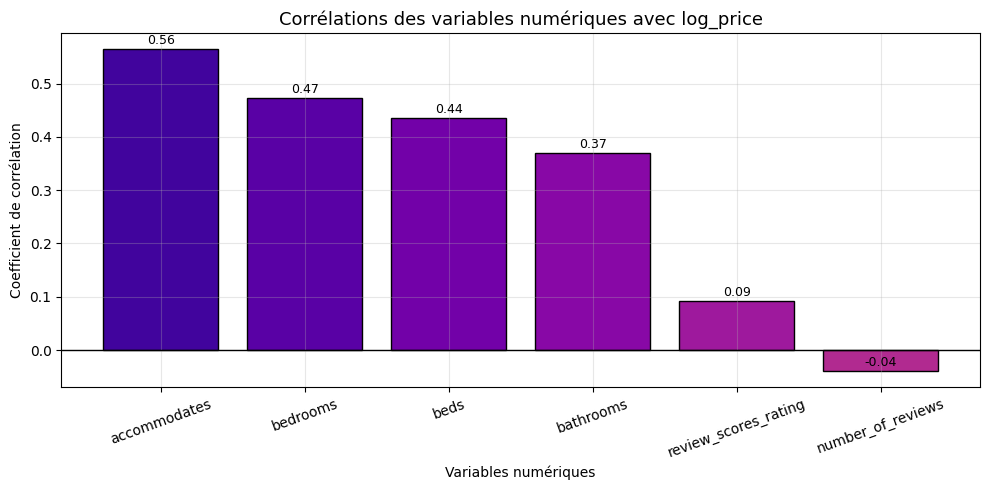

In [6]:
# On va étudier et visualiser la coorélation dans les différentes catégories numérique avec log_price

colonnesnumeriques = ['accommodates','bathrooms','bedrooms','beds','number_of_reviews','review_scores_rating']

donnees = train[colonnesnumeriques + ['log_price']].copy()

for colonne in colonnesnumeriques:
    donnees[colonne] = pd.to_numeric(donnees[colonne], errors='coerce')

correlations = (donnees.corr()['log_price'].drop('log_price').sort_values(key=abs, ascending=False))

plt.figure(figsize=(10, 5))

couleurs = plt.cm.plasma(np.linspace(0.1, 0.4, len(correlations)))

barres = plt.bar(
    correlations.index,
    correlations.values,
    color=couleurs,
    edgecolor='black'
)

plt.axhline(0, color='black', linewidth=1)

plt.title("Corrélations des variables numériques avec log_price", fontsize=13)
plt.xlabel("Variables numériques")
plt.ylabel("Coefficient de corrélation")

plt.xticks(rotation=20)

for barre, valeur in zip(barres, correlations.values):
    plt.text(
        barre.get_x() + barre.get_width()/2,
        valeur + 0.01,
        f"{valeur:.2f}",
        ha='center',
        fontsize=9
    )

plt.tight_layout()
plt.show()

### Observations : corrélations numériques

- Plus le logement est grand (voyageurs, chambres, salles de bain), plus il est cher
- Les logements avec le plus d'avis sont moins cher (car moins cher donne plus de location donc plus de reviews)
- La note des avis a un effet faible sur le prix en comparasion avec ce que l'on aurait pu attendre

On observe que c'est la taille du logement qui influence le plus fort le prix

Nous allons maintenant nous pencher sur une analyse de donnée plus approfondie pour mieux comprendre notre set avec :
- **Analyse géographique** 
- **Correlation des variables numériques** 
- **Impact des equipements** 
- **Analyse de prix selon le type et la taille du logement** 
- **Popularité des équipements** 
- **Impact des booleens**


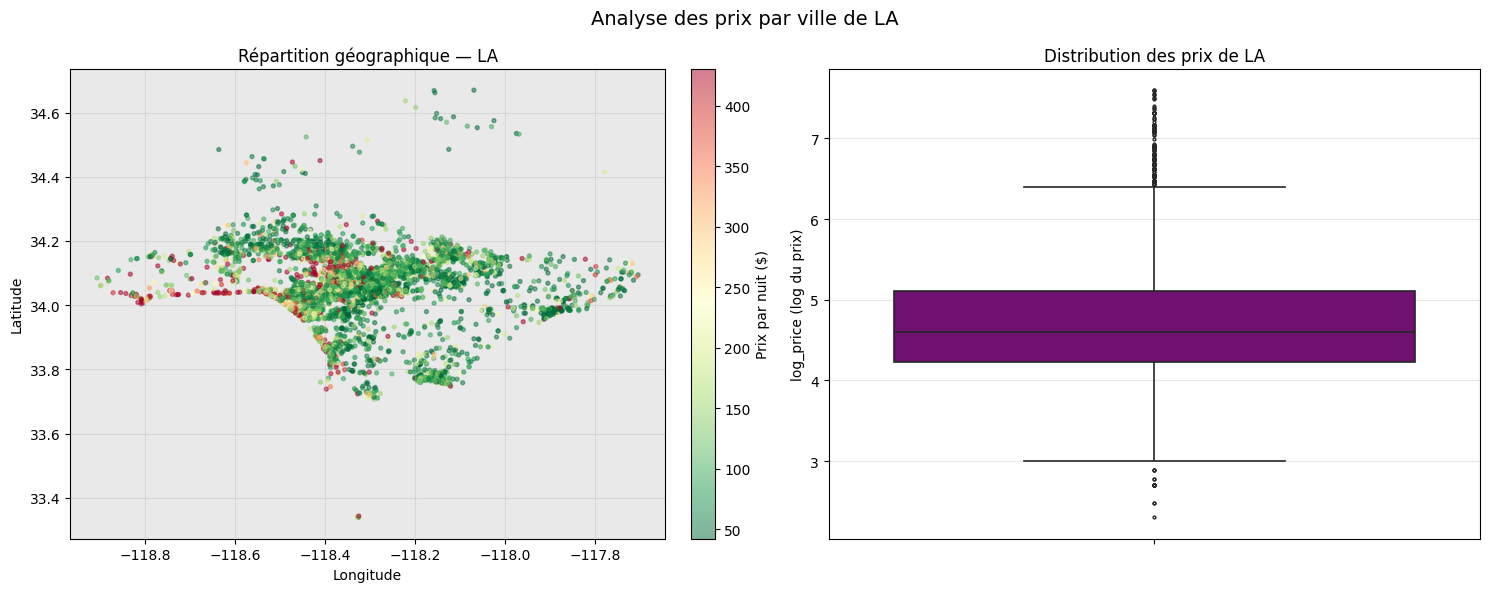

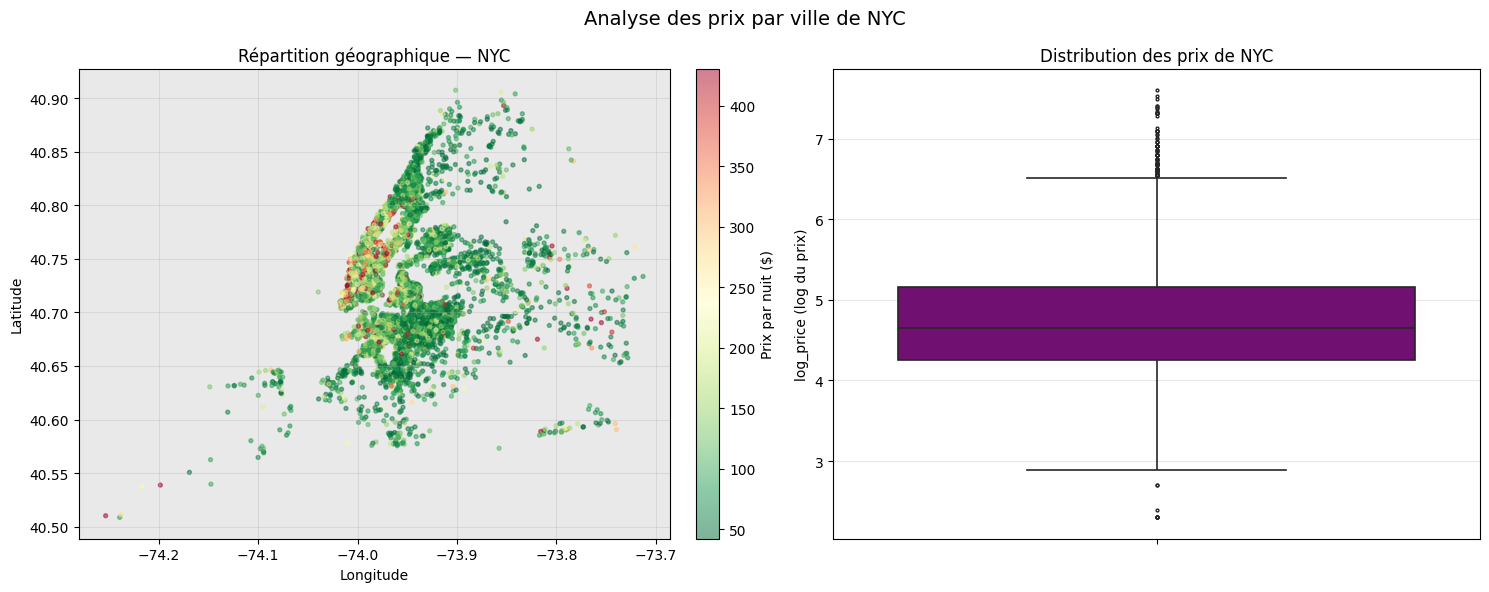

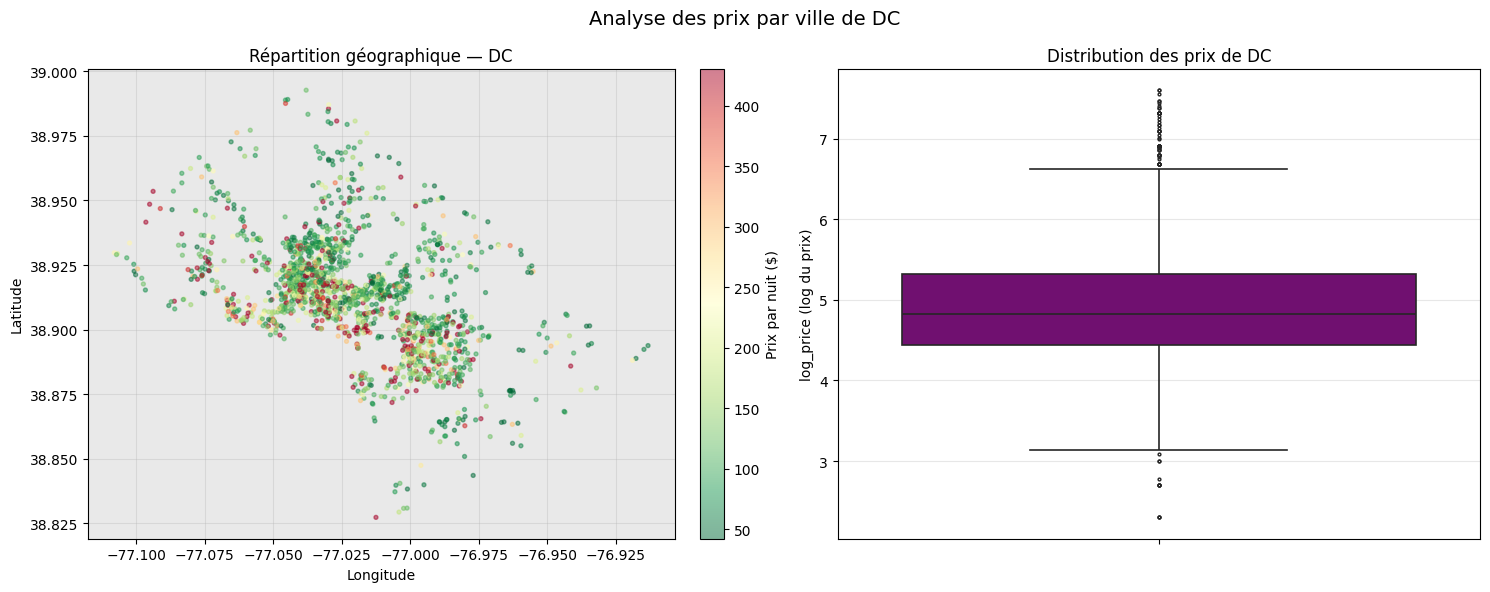

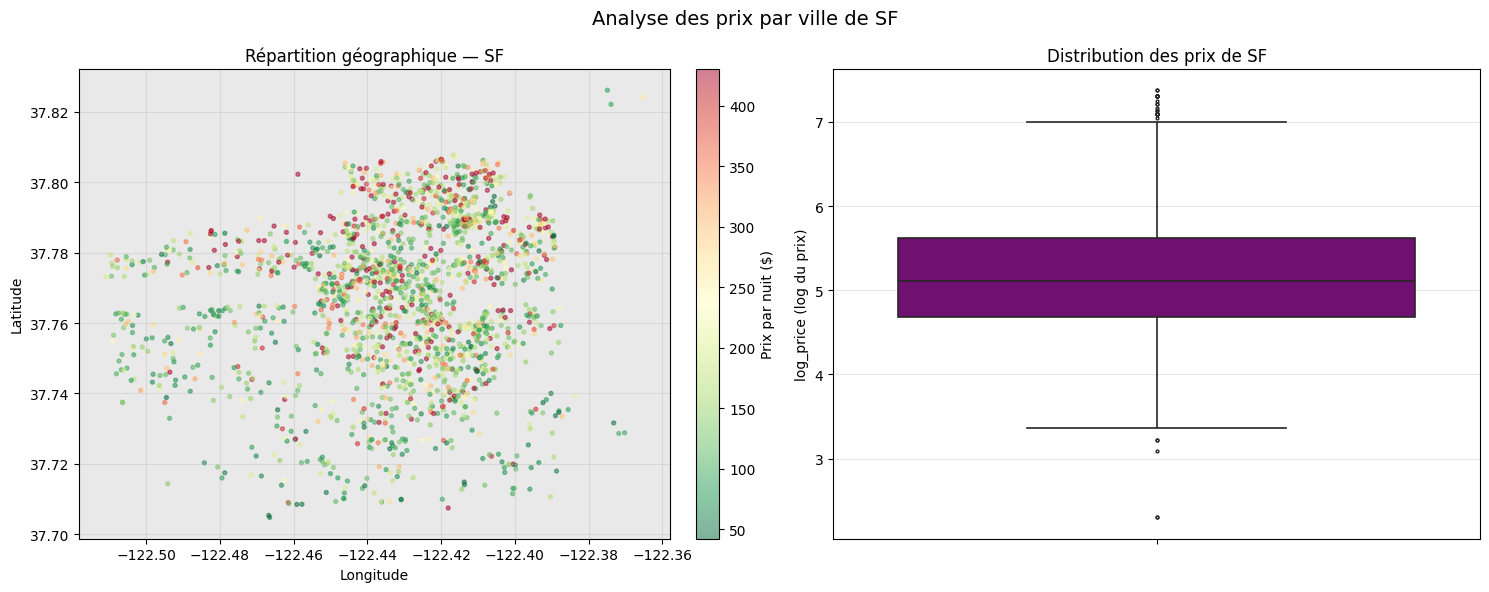

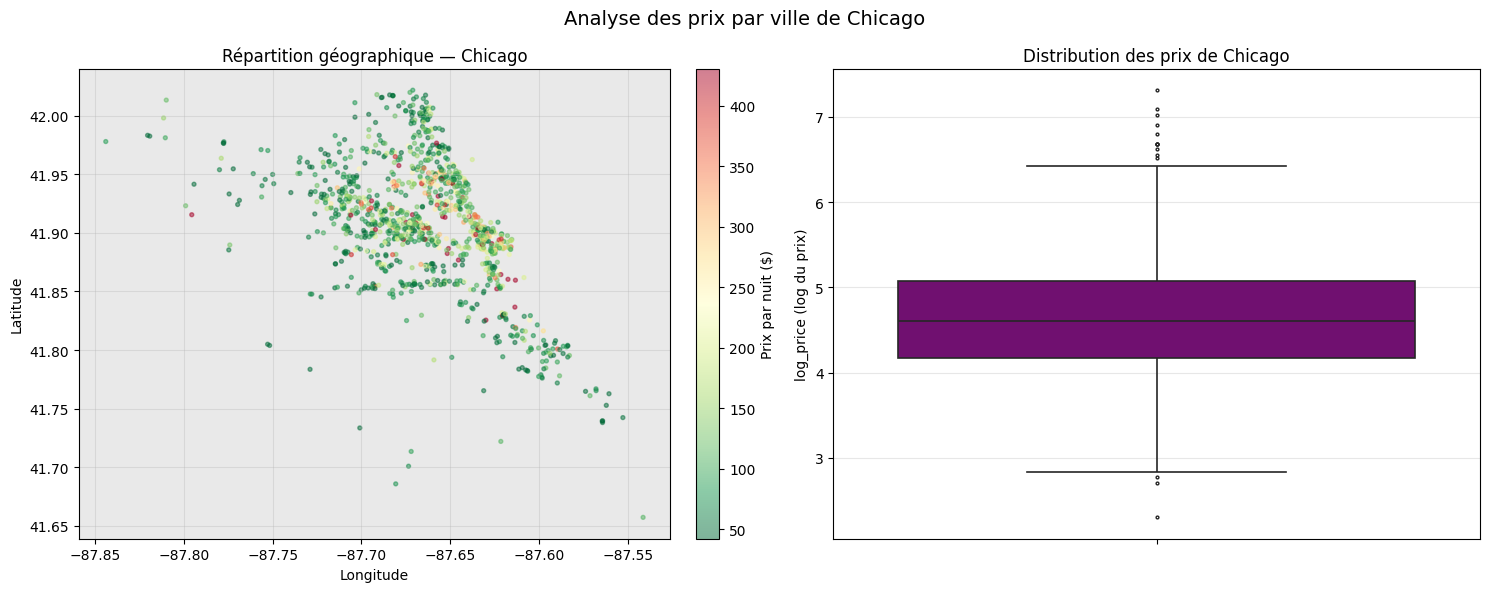

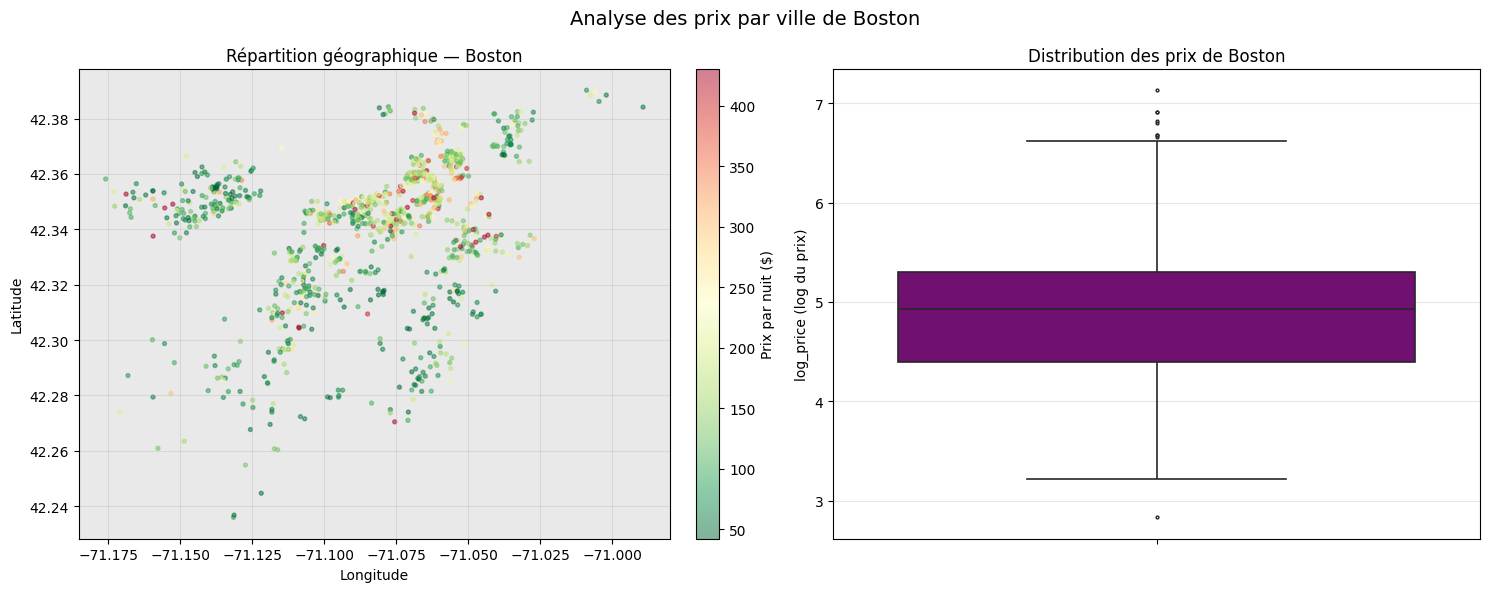

In [7]:
# Carte+Boxplot pour chaque ville

import seaborn as sns

prixnuit = np.exp(train['log_price'])
percentilebas, percentilehaut = np.percentile(prixnuit, 5), np.percentile(prixnuit, 95)

listesvilles = train['city'].unique()

for nomville in listesvilles:

    donneesfiltrees = train[train['city'] == nomville]
    prixfiltre = np.exp(donneesfiltrees['log_price'])

    figure, axesgraph = plt.subplots(1, 2, figsize=(15, 6))

    carte = axesgraph[0].scatter(
        donneesfiltrees['longitude'],
        donneesfiltrees['latitude'],
        c=prixfiltre.clip(percentilebas, percentilehaut),
        cmap='RdYlGn_r',
        s=8,
        alpha=0.5,
        vmin=percentilebas,
        vmax=percentilehaut
    )

    axesgraph[0].set_title(f'Répartition géographique — {nomville}', fontsize=12)
    axesgraph[0].set_xlabel('Longitude')
    axesgraph[0].set_ylabel('Latitude')
    axesgraph[0].set_facecolor('#e9e9e9')

    barredecouleur = plt.colorbar(carte, ax=axesgraph[0], fraction=0.046, pad=0.04)
    barredecouleur.set_label('Prix par nuit ($)')

    sns.boxplot(
        data=donneesfiltrees,
        y='log_price',
        ax=axesgraph[1],
        color='purple',
        linewidth=1.2,
        fliersize=2
    )

    axesgraph[1].set_title(f'Distribution des prix de {nomville}', fontsize=12)
    axesgraph[1].set_ylabel('log_price (log du prix)')
    axesgraph[1].set_xlabel('')
    axesgraph[1].grid(axis='y', alpha=0.3)

    plt.suptitle(f'Analyse des prix par ville de {nomville}', fontsize=14)
    plt.tight_layout()
    plt.show()

### Observations Ville par Ville
- **La carte géographique** met en évidence le lien entre le prix du logement et sa localisation 
- **Les Boxplots** nous confirment le lien entre la ville et la moyenne de prix mais nous permettent d'observer qu'au sein d'une même ville la distribution est relativement similaire


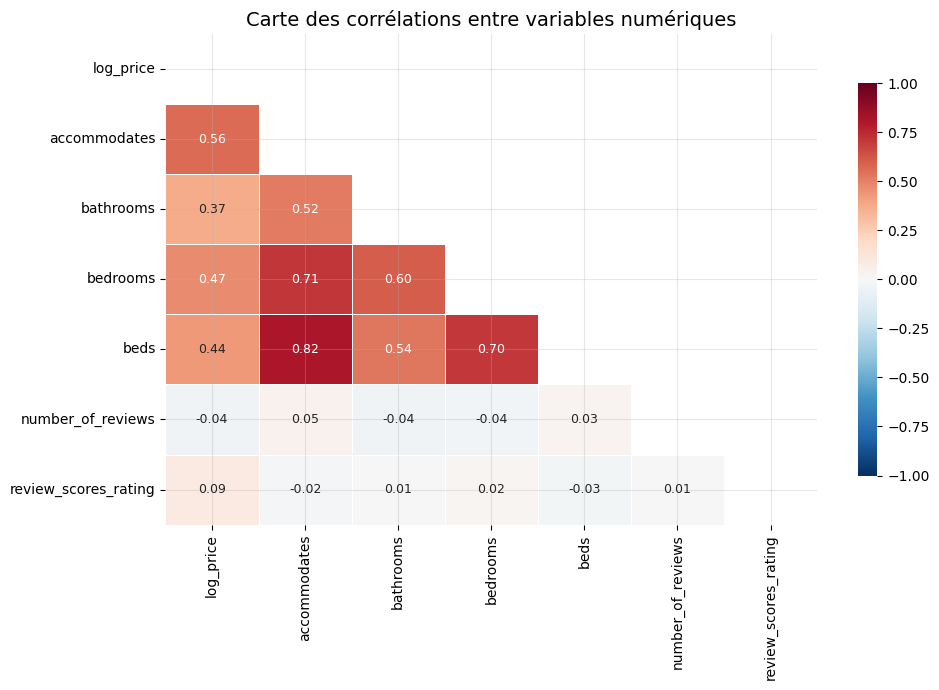

In [8]:
# Heatmap des corrélations entre variables numériques 

import seaborn as sns

variablesnumeriques = ['log_price', 'accommodates', 'bathrooms', 'bedrooms', 'beds','number_of_reviews', 'review_scores_rating']



donneescorr = train[variablesnumeriques].copy()

for variable in variablesnumeriques:
    donneescorr[variable] = pd.to_numeric(donneescorr[variable], errors='coerce')

matricecorr = donneescorr.corr()
masque = np.triu(np.ones_like(matricecorr, dtype=bool))


plt.figure(figsize=(10, 7))

sns.heatmap(
    matricecorr,
    mask=masque,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    linewidths=0.6,
    linecolor="white",
    annot_kws={"size": 9},
    vmin=-1,
    vmax=1,
    cbar_kws={"shrink": 0.8}
)

plt.title("Carte des corrélations entre variables numériques", fontsize=14)
plt.tight_layout()
plt.show()

### Observations : Matrice de Corrélation 
- **La matrice de correlation** permet de mettre en évident le lien entre toutes les colonnes relatives à la taille du logement ainsi qu'une très faible corrélation entre le reste des variables


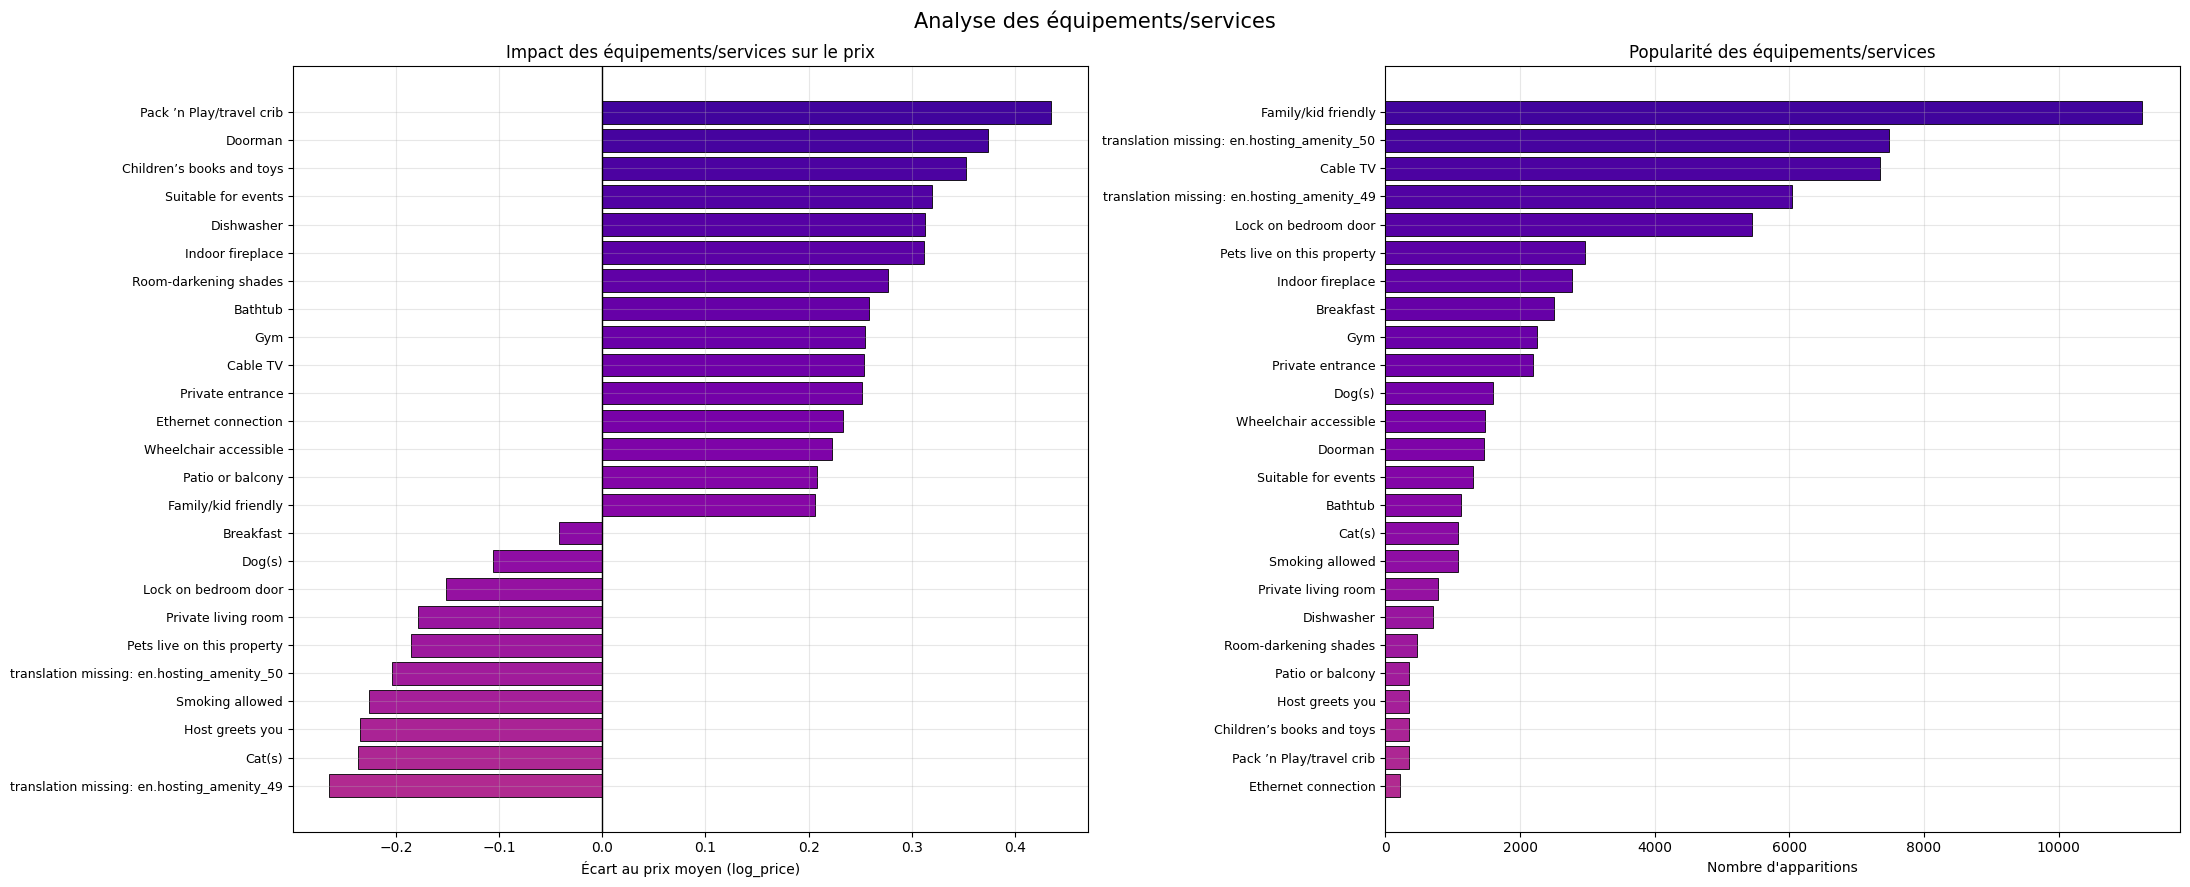

In [9]:
# Visualisation de la popularité et de l'impact sur le log_price des différents equipements et services

def extraireequipserv(chaine):
    if pd.isna(chaine):
        return []
    return [
        element.strip().strip('"')
        for element in str(chaine).strip('{}').split(',')
        if element.strip().strip('"')
    ]

dictionnaireequipserv = {}

for _, ligne in train.iterrows():
    for equipserv in extraireequipserv(ligne['amenities']):
        dictionnaireequipserv.setdefault(equipserv, []).append(ligne['log_price'])

tableequipserv = pd.DataFrame([
    {
        'equipserv': cle,
        'moyenne_log': np.mean(valeurs),
        'occurrence': len(valeurs)
    }
    for cle, valeurs in dictionnaireequipserv.items()
    if len(valeurs) >= 200
]).sort_values('moyenne_log', ascending=False)

moyenneglobale = train['log_price'].mean()

topequipserv = tableequipserv.head(15).copy()
basequipserv = tableequipserv.tail(10).copy()

tablefinale = pd.concat([topequipserv, basequipserv]).reset_index(drop=True)
tablefinale['ecart'] = tablefinale['moyenne_log'] - moyenneglobale

palettecouleurs = plt.cm.plasma(np.linspace(0.1, 0.4, len(tablefinale)))

fig, axes = plt.subplots(1, 2, figsize=(22, 9))

axes[0].barh(
    range(len(tablefinale)),
    tablefinale['ecart'],
    color=palettecouleurs,
    edgecolor='black',
    linewidth=0.6
)

axes[0].axvline(0, color='black', linewidth=1)
axes[0].set_yticks(range(len(tablefinale)))
axes[0].set_yticklabels(tablefinale['equipserv'], fontsize=9)
axes[0].invert_yaxis()
axes[0].set_xlabel('Écart au prix moyen (log_price)')
axes[0].set_title("Impact des équipements/services sur le prix")
axes[0].grid(axis='x', alpha=0.3)

tablefreq = tablefinale.sort_values('occurrence', ascending=False).reset_index(drop=True)

axes[1].barh(
    range(len(tablefreq)),
    tablefreq['occurrence'],
    color=palettecouleurs,
    edgecolor='black',
    linewidth=0.6
)

axes[1].set_yticks(range(len(tablefreq)))
axes[1].set_yticklabels(tablefreq['equipserv'], fontsize=9)
axes[1].invert_yaxis()
axes[1].set_xlabel("Nombre d'apparitions")
axes[1].set_title("Popularité des équipements/services")
axes[1].grid(axis='x', alpha=0.3)

plt.suptitle("Analyse des équipements/services", fontsize=15)
plt.tight_layout()
plt.show()

### Observations : Equipements
- **Impact des equipements sur le prix** montre le réel impact sur le prix des différents equipements et services
- **Popularité des equipements/service** montre la popularité des differents equipements

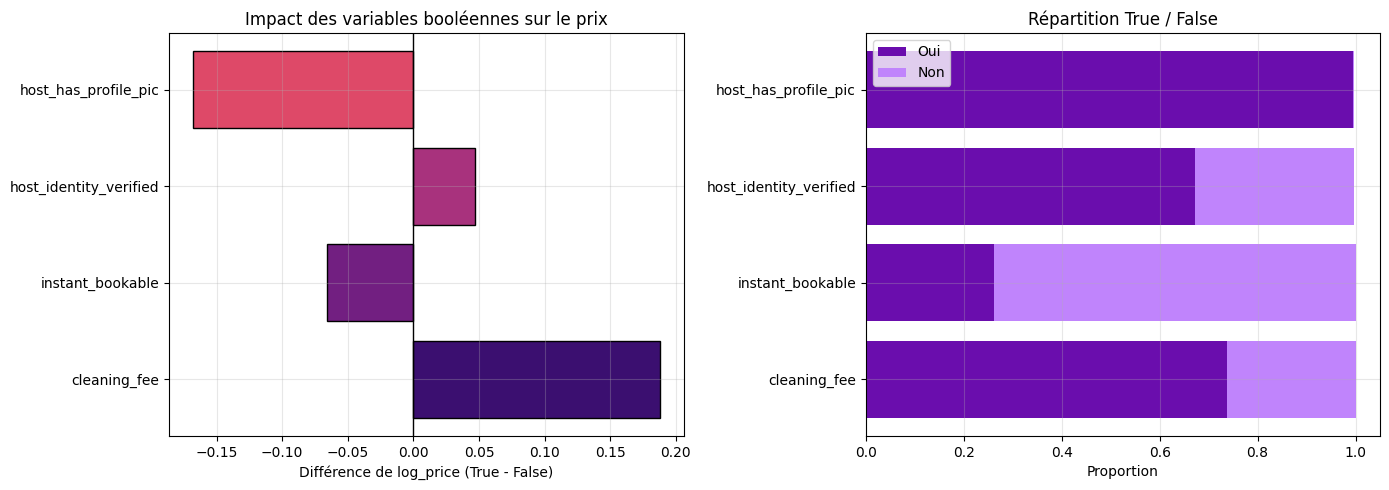

In [10]:
# Visualisation de l'impact sur le prix des données booleenes et leur proportion de true/false
import seaborn as sns

boolcols = [
    'cleaning_fee',
    'instant_bookable',
    'host_identity_verified',
    'host_has_profile_pic'
]

resultats = []

for col in boolcols:
    tmp = train.copy()
    tmp[col] = tmp[col].astype(str).str.lower()

    oui = tmp[tmp[col].isin(['t', 'true', '1'])]
    non = tmp[tmp[col].isin(['f', 'false', '0'])]

    resultats.append({
        'variable': col,
        'diff_log_price': oui['log_price'].mean() - non['log_price'].mean(),
        'freq_true': len(oui) / len(tmp),
        'freq_false': len(non) / len(tmp)
    })

df_bool = pd.DataFrame(resultats)

# palette violette
couleurs = plt.cm.magma(np.linspace(0.2, 0.6, len(df_bool)))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].barh(
    df_bool['variable'],
    df_bool['diff_log_price'],
    color=couleurs,
    edgecolor='black'
)

axes[0].axvline(0, color='black', linewidth=1)
axes[0].set_title("Impact des variables booléennes sur le prix")
axes[0].set_xlabel("Différence de log_price (True - False)")
axes[0].grid(axis='x', alpha=0.3)

axes[1].barh(
    df_bool['variable'],
    df_bool['freq_true'],
    color='#6a0dad',
    label='Oui'
)

axes[1].barh(
    df_bool['variable'],
    df_bool['freq_false'],
    left=df_bool['freq_true'],
    color='#c084fc',
    label='Non'
)

axes[1].set_title("Répartition True / False")
axes[1].set_xlabel("Proportion")
axes[1].legend()
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

### Observations : Boolens
- **Impact des booleens sur le prix** montre le réel impact sur le prix des boolens
- **Proportion des booleens** montre la popularité des differents booleens

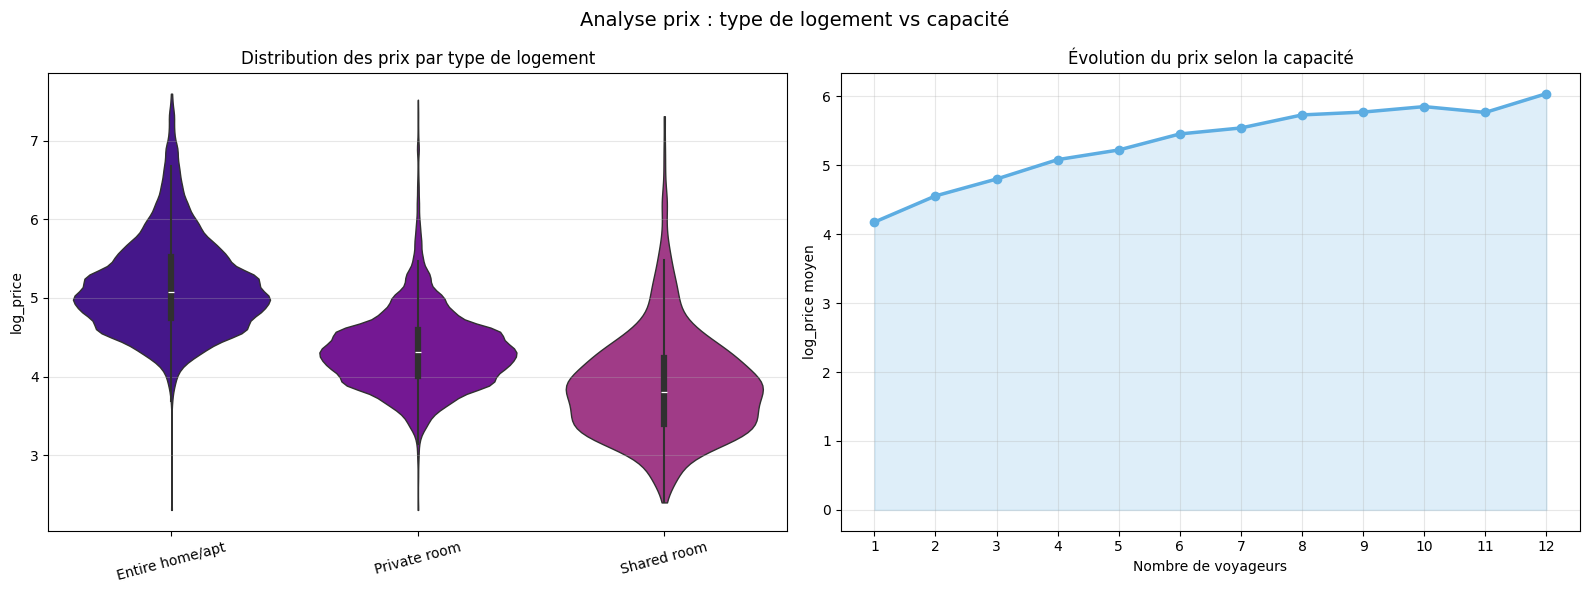

In [11]:
# Visualisation de la distribution des prix selon le type de logement et selon sa capacité

import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(16, 6))


ordre_type = (
    train.groupby('room_type')['log_price']
    .median()
    .sort_values(ascending=False)
    .index.tolist()
)
sns.violinplot(
    data=train,
    x='room_type',
    y='log_price',
    order=ordre_type,
    palette=plt.cm.plasma(np.linspace(0.1, 0.4, len(ordre_type))),
    inner='box',
    cut=0,
    linewidth=1,
    ax=axes[0]
)

axes[0].set_title('Distribution des prix par type de logement')
axes[0].set_xlabel('')
axes[0].set_ylabel('log_price')
axes[0].tick_params(axis='x', rotation=15)
axes[0].grid(axis='y', alpha=0.3)

donneesacc = train.copy()
donneesacc['accommodates'] = pd.to_numeric(donneesacc['accommodates'], errors='coerce')
donneesacc = donneesacc.dropna(subset=['accommodates'])

donneesacc['bin_capacite'] = donneesacc['accommodates'].clip(1, 12).astype(int)

moyennesacc = donneesacc.groupby('bin_capacite')['log_price'].mean()

axes[1].plot(
    moyennesacc.index,
    moyennesacc.values,
    marker='o',
    linewidth=2.5,
    color='#5dade2'
)

axes[1].fill_between(
    moyennesacc.index,
    moyennesacc.values,
    alpha=0.2,
    color='#5dade2'
)

axes[1].set_title('Évolution du prix selon la capacité')
axes[1].set_xlabel('Nombre de voyageurs')
axes[1].set_ylabel('log_price moyen')
axes[1].set_xticks(moyennesacc.index)
axes[1].grid(alpha=0.3)

plt.suptitle('Analyse prix : type de logement vs capacité', fontsize=14)
plt.tight_layout()
plt.show()

### Observations Analyse de prix : 
- **Le violin** nous permet d'observer que la distribution des log_price est plus centrée pour les private room et plus étendue pour les shared room
- **Le graphique** nous permet d'observer la correlation positive entre le log_price et le nombre de voyageurs sauf pour 11 mais c'est du a la faible quantité de données pour des logements de 11 personnes.

### Bilan Général de l’Analyse Exploratoire

- Le prix des logements dépend surtout de la taille du logement (nombre de voyageurs, chambres, lits, salles de bain)
- Les variables catégorielles comme la ville, le type de logement ou la politique d’annulation ont également un impact important sur le prix
- Les logements entiers et les logements plus haut de gamme sont globalement plus chers
- La localisation géographique influence fortement les prix avec certaines zones beaucoup plus chères que d’autres

### Bilan des Variables Numériques

- Les variables liées à la capacité et au confort du logement sont les plus corrélées avec le `log_price`
- Les avis utilisateurs ont finalement un impact assez faible sur le prix
- Les logements les moins chers semblent avoir plus de réservations et donc davantage d’avis

### Bilan des Equipements et Services

- Certains équipements/services augmentent clairement le prix du logement
- Les équipements les plus premium sont souvent moins fréquents mais associés à des logements plus chers
- Les équipements très présents dans les annonces ne sont pas forcément ceux qui augmentent le plus le prix

### Bilan des Variables Booléennes

- Les variables booléennes ont un réel impact sur le prix des logements
- Les logements avec frais de ménage, réservation instantanée ou hôte vérifié ont tendance à être légèrement plus chers
- Certaines modalités booléennes sont très largement dominantes dans le dataset

### Bilan des Distributions de Prix

- Les distributions de prix changent selon le type de logement
- Les private rooms ont une distribution plus resserrée alors que d’autres catégories présentent une plus grande dispersion
- Le prix moyen augmente globalement avec la capacité d’accueil du logement

### Conclusion Générale

Cette analyse exploratoire montre que le prix d’un logement Airbnb dépend principalement :
- de la taille du logement,
- de sa localisation,
- de son type,
- ainsi que des équipements et services proposés.

Les différentes analyses mettent en évidence des relations cohérentes avec le `log_price`, ce qui confirme que les variables choisies semblent pertinentes pour la suite du projet et pour la mise en place des modèles de prédiction.

## 3. Feature Engineering

Le modèle de machine learning ne peut travailler qu’avec des valeurs numériques.  
Il a donc fallu transformer plusieurs colonnes du dataset avant l’entraînement.

- Les colonnes contenant des listes d’équipements (`amenities`) ont été transformées en plusieurs colonnes binaires (0/1) afin d’indiquer la présence ou non de certains équipements comme le WiFi, la climatisation ou le parking.

- Les colonnes de dates (`host_since`, `first_review`, `last_review`) ont été converties en nombre de jours par rapport à une date de référence. Cela permet au modèle d’exploiter l’ancienneté d’un hôte ou l’activité récente d’un logement.

- Les variables booléennes contenant des valeurs `t` / `f` ont été converties en `1` et `0` pour être interprétées correctement par les modèles.

- Les colonnes textuelles comme `description` ou `name` ont été simplifiées en utilisant par exemple leur longueur en caractères. Une description plus détaillée peut par exemple refléter un logement mieux présenté.

- Les taux de réponse des hôtes (`host_response_rate`) ont été convertis en nombres décimaux (`90%` → `0.9`) afin d’obtenir une variable exploitable numériquement.

- Certaines colonnes catégorielles comme `zipcode` ou `neighbourhood` ont également été nettoyées avant l’étape d’encodage pour éviter les incohérences dans les valeurs.

In [12]:
# Fonction pour extraire les équipements/services
def extraireequipserv(chaine):

    if pd.isna(chaine) or chaine == '':
        return []

    listeequipserv = []

    for element in str(chaine).strip('{}').split(','):

        element = element.strip().strip('"').strip()

        if element:
            listeequipserv.append(element)

    return listeequipserv


# On récupère les 35 équipements/services les plus présents dans le train

listecomplete = []

for valeur in train['amenities']:
    listecomplete.extend(extraireequipserv(valeur))

compteurequipserv = Counter(listecomplete)

TOP_EQUIPSERV = [
    equipserv
    for equipserv, _ in compteurequipserv.most_common(35)
]

print("Top 35 équipements/services :\n")

for indice, (equipserv, nb) in enumerate(compteurequipserv.most_common(35), 1):

    print(f"{indice:2d}. {equipserv:<45} ({nb:,})")


# Fonction principale de feature engineering

def creerfeatures(dataframe):

    dataframe = dataframe.copy()

    # On transforme les équipements/services en colonnes binaires

    equipservparse = dataframe['amenities'].apply(extraireequipserv)

    dataframe['nombre_equipserv'] = equipservparse.apply(len)

    for equipserv in TOP_EQUIPSERV:

        nomcolonne = 'equipserv_' + re.sub(r'[^a-z0-9]', '_', equipserv.lower())[:35]

        dataframe[nomcolonne] = equipservparse.apply(
            lambda liste: 1 if equipserv in liste else 0
        )

    # On transforme les dates en nombre de jours

    dateref = pd.Timestamp('2018-01-01')

    for colonne in ['host_since', 'first_review', 'last_review']:

        datesconverties = pd.to_datetime(dataframe[colonne], errors='coerce')

        dataframe[colonne + '_jours'] = (dateref - datesconverties).dt.days

        dataframe[colonne + '_manquant'] = datesconverties.isna().astype(int)

    # On transforme les booléens en 0 et 1

    for colonne in [
        'host_has_profile_pic',
        'host_identity_verified',
        'instant_bookable'
    ]:

        dataframe[colonne] = (
            dataframe[colonne]
            .astype(str)
            .str.lower()
            .eq('t')
            .astype(int)
        )

    dataframe['cleaning_fee'] = (
        dataframe['cleaning_fee']
        .astype(str)
        .str.lower()
        .eq('true')
        .astype(int)
    )

    # On transforme les pourcentages en décimal

    def convertirtaux(valeur):

        try:
            return float(str(valeur).replace('%', '').strip()) / 100

        except Exception:
            return np.nan

    dataframe['host_response_rate'] = dataframe['host_response_rate'].apply(
        lambda x:
        np.nan
        if pd.isna(x) or str(x).strip() == ''
        else convertirtaux(x)
    )

    # On récupère des infos sur les textes

    dataframe['taille_description'] = dataframe['description'].fillna('').apply(len)

    dataframe['mots_description'] = dataframe['description'].fillna('').apply(
        lambda texte: len(texte.split())
    )

    dataframe['taille_nom'] = dataframe['name'].fillna('').apply(len)

    # On convertit les colonnes numériques

    for colonne in [
        'bathrooms',
        'bedrooms',
        'beds',
        'review_scores_rating',
        'number_of_reviews',
        'accommodates'
    ]:

        dataframe[colonne] = pd.to_numeric(dataframe[colonne], errors='coerce')

    # On ajoute une colonne pour les reviews manquantes

    dataframe['review_manquante'] = dataframe['review_scores_rating'].isna().astype(int)

    # On nettoie les colonnes catégorielles

    dataframe['zipcode_clean'] = dataframe['zipcode'].fillna('Unknown').astype(str).str.strip().str[:5]

    dataframe['neighbourhood_clean'] = dataframe['neighbourhood'].fillna('Unknown').astype(str).str.strip()

    return dataframe


# On applique le feature engineering sur train et test

train_fe = creerfeatures(train)

test_fe = creerfeatures(test)

print(f"\nNombre total de colonnes après feature engineering : {train_fe.shape[1]}")

Top 35 équipements/services :

 1. Wireless Internet                             (21,400)
 2. Kitchen                                       (20,199)
 3. Heating                                       (20,156)
 4. Essentials                                    (19,224)
 5. Smoke detector                                (18,587)
 6. Air conditioning                              (16,571)
 7. TV                                            (15,809)
 8. Shampoo                                       (14,847)
 9. Hangers                                       (14,713)
10. Carbon monoxide detector                      (14,224)
11. Internet                                      (13,470)
12. Laptop friendly workspace                     (13,055)
13. Washer                                        (13,034)
14. Hair dryer                                    (12,984)
15. Dryer                                         (12,870)
16. Iron                                          (12,543)
17. Family/kid friendly  

## 4. Encodage des Variables Catégorielles

Les modèles de machine learning ne peuvent pas directement interpréter des valeurs textuelles comme `NYC`, `Apartment` ou `Entire home/apt`.  
Il faut donc transformer ces colonnes en valeurs numériques exploitables.

- Pour les colonnes avec énormément de valeurs différentes comme les quartiers ou les codes postaux, on utilise du **target encoding**.  
  Chaque catégorie est remplacée par le prix moyen (`log_price`) observé dans cette catégorie.  
  Par exemple, un quartier avec des logements chers aura une valeur plus élevée qu’un quartier plus abordable.

- Pour éviter les fuites de données pendant l’entraînement, cette moyenne est calculée uniquement sur les données d’apprentissage de chaque fold de validation.

- Pour les autres variables catégorielles avec moins de modalités (`room_type`, `city`, `property_type`...), on utilise un **label encoding**.  
  Chaque catégorie reçoit simplement un identifiant numérique.

In [13]:
# Fonction de target encoding
def target_encode(
    train_df,
    test_df,
    cols,
    target='log_price',
    n_splits=5,
    smoothing=10
):

    moyenneglobale = train_df[target].mean()

    for colonne in cols:

        colonneencodee = np.full(
            len(train_df),
            moyenneglobale,
            dtype=float
        )

        kfold = KFold(
            n_splits=n_splits,
            shuffle=True,
            random_state=SEED
        )

        for indextrain, indexvalid in kfold.split(train_df):

            donneestrain = train_df.iloc[indextrain]
            donneesvalid = train_df.iloc[indexvalid]

            statistiques = (
                donneestrain
                .groupby(colonne)[target]
                .agg(['mean', 'count'])
            )

            moyennecorrigee = (
                statistiques['count'] * statistiques['mean']
                + smoothing * moyenneglobale
            ) / (statistiques['count'] + smoothing)

            colonneencodee[indexvalid] = (
                donneesvalid[colonne]
                .map(moyennecorrigee)
                .fillna(moyenneglobale)
                .values
            )

        statistiquesglobales = (
            train_df
            .groupby(colonne)[target]
            .agg(['mean', 'count'])
        )

        moyennefinale = (
            statistiquesglobales['count'] * statistiquesglobales['mean']
            + smoothing * moyenneglobale
        ) / (statistiquesglobales['count'] + smoothing)

        train_df[colonne + '_te'] = colonneencodee

        test_df[colonne + '_te'] = (
            test_df[colonne]
            .map(moyennefinale)
            .fillna(moyenneglobale)
            .values
        )

    return train_df, test_df


# Fonction de label encoding

def label_encode(train_df, test_df, cols):

    for colonne in cols:

        encodeur = LabelEncoder()

        donneesfusionnees = pd.concat([
            train_df[colonne].fillna('Unknown').astype(str),
            test_df[colonne].fillna('Unknown').astype(str)
        ], ignore_index=True)

        encodeur.fit(donneesfusionnees)

        train_df[colonne + '_le'] = encodeur.transform(
            train_df[colonne]
            .fillna('Unknown')
            .astype(str)
        )

        test_df[colonne + '_le'] = encodeur.transform(
            test_df[colonne]
            .fillna('Unknown')
            .astype(str)
        )

    return train_df, test_df


# Colonnes utilisées pour les encodages

TE_COLS = [
    'neighbourhood_clean',
    'zipcode_clean'
]

LE_COLS = [
    'property_type',
    'room_type',
    'bed_type',
    'cancellation_policy',
    'city'
]


# Application des encodages

train_enc, test_enc = target_encode(
    train_fe,
    test_fe,
    TE_COLS
)

train_enc, test_enc = label_encode(
    train_enc,
    test_enc,
    LE_COLS
)

print("Encodage terminé")


# Variables numériques

NUM_FEAT = [

    'accommodates',
    'bathrooms',
    'bedrooms',
    'beds',

    'number_of_reviews',
    'review_scores_rating',

    'latitude',
    'longitude',

    'nombre_equipserv',

    'taille_description',
    'mots_description',
    'taille_nom',

    'host_response_rate',

    'host_since_jours',
    'first_review_jours',
    'last_review_jours',

    'host_since_manquant',
    'first_review_manquant',
    'last_review_manquant',

    'review_manquante',

    'host_has_profile_pic',
    'host_identity_verified',
    'instant_bookable',
    'cleaning_fee',
]


# Features target encoded

TE_FEAT = [
    colonne + '_te'
    for colonne in TE_COLS
]


# Features label encoded

LE_FEAT = [
    colonne + '_le'
    for colonne in LE_COLS
]


# Features équipements/services

EQUIPSERV_FEAT = [

    colonne
    for colonne in train_enc.columns
    if colonne.startswith('equipserv_')
]


# Toutes les features

ALL_FEAT = (
    NUM_FEAT
    + TE_FEAT
    + LE_FEAT
    + EQUIPSERV_FEAT
)


# Affichage du nombre de variables

print(f"\nTotal features : {len(ALL_FEAT)}")

print(f"Numériques        : {len(NUM_FEAT)}")

print(f"Target encoded    : {len(TE_FEAT)}")

print(f"Label encoded     : {len(LE_FEAT)}")

print(f"Equip/services    : {len(EQUIPSERV_FEAT)}")


# Création des datasets finaux

X = train_enc[ALL_FEAT].copy()

y = train_enc['log_price'].copy()

X_test = test_enc[ALL_FEAT].copy()


# Remplacement des NaN par les médianes

medianes = X.median()

X = X.fillna(medianes)

X_test = X_test.fillna(medianes)


# Vérifications finales

print(f"\nX      : {X.shape}")

print(
    f"y      : {y.shape} | "
    f"mean={y.mean():.3f} | "
    f"std={y.std():.3f}"
)

print(f"X_test : {X_test.shape}")

print(f"NaN dans X      : {X.isna().sum().sum()}")

print(f"NaN dans X_test : {X_test.isna().sum().sum()}")

Encodage terminé

Total features : 65
Numériques        : 24
Target encoded    : 2
Label encoded     : 5
Equip/services    : 34

X      : (22234, 65)
y      : (22234,) | mean=4.783 | std=0.719
X_test : (51877, 65)
NaN dans X      : 0
NaN dans X_test : 0


## 5. Exploration des Modèles et Configurations

Avant de choisir le modèle final, on teste plusieurs approches pour justifier nos choix.

1. **Comparaison de modèles** : Ridge, Random Forest, Gradient Boosting, LightGBM — même jeu de features, pour voir quel algorithme marche le mieux
2. **Comparaison de configurations** : du jeu de features minimal au complet — pour voir l'apport de chaque groupe de variables

On utilise une validation croisée 3-fold (plus rapide) pour comparer.

In [14]:
# Imports nécessaires pour les modèles
import numpy as np
import pandas as pd

from sklearn.linear_model import Ridge
from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor,
    ExtraTreesRegressor
)
from sklearn.neighbors import KNeighborsRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error

from lightgbm import LGBMRegressor


# Validation croisée
SEED = 42

kfold3 = KFold(
    n_splits=3,
    shuffle=True,
    random_state=SEED
)

# Liste des modèles testés
modeles = {
    'Ridge': Pipeline([
        ('scaler', StandardScaler()),
        ('modele', Ridge(alpha=10))
    ]),

    'Random Forest': RandomForestRegressor(
        n_estimators=120,
        max_depth=18,
        min_samples_leaf=2,
        random_state=SEED,
        n_jobs=-1
    ),

    'Gradient Boosting': GradientBoostingRegressor(
        n_estimators=250,
        learning_rate=0.05,
        max_depth=4,
        random_state=SEED
    ),

    'Extra Trees': ExtraTreesRegressor(
        n_estimators=150,
        max_depth=20,
        min_samples_leaf=2,
        random_state=SEED,
        n_jobs=-1
    ),

    'KNN': Pipeline([
        ('scaler', StandardScaler()),
        ('modele', KNeighborsRegressor(n_neighbors=12))
    ]),

    'LightGBM': LGBMRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=-1,
        random_state=SEED
    )
}


# Comparaison des modèles
resultatsmodeles = []

for nommodele, modele in modeles.items():
    scoresfolds = []

    for indextrain, indexvalid in kfold3.split(X):
        Xtrain = X.iloc[indextrain]
        Xvalid = X.iloc[indexvalid]
        ytrain = y.iloc[indextrain]
        yvalid = y.iloc[indexvalid]

        modele.fit(Xtrain, ytrain)
        predictions = modele.predict(Xvalid)

        rmse = np.sqrt(mean_squared_error(yvalid, predictions))
        scoresfolds.append(rmse)

    resultatsmodeles.append({
        'modele': nommodele,
        'rmse_moyen': np.mean(scoresfolds),
        'rmse_std': np.std(scoresfolds)
    })


# Tableau récapitulatif
resultatsdf = (
    pd.DataFrame(resultatsmodeles)
    .sort_values('rmse_moyen')
    .reset_index(drop=True)
)

print(resultatsdf)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003934 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2879
[LightGBM] [Info] Number of data points in the train set: 14822, number of used features: 65
[LightGBM] [Info] Start training from score 4.781456
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.006588 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2884
[LightGBM] [Info] Number of data points in the train set: 14823, number of used features: 65
[LightGBM] [Info] Start training from score 4.778736
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003127 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bi

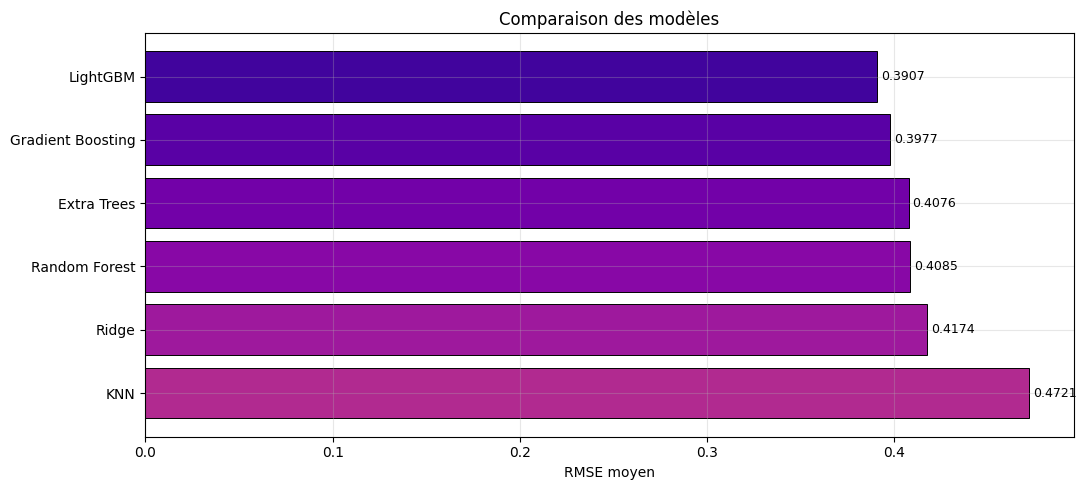

In [15]:
# Visualisation des performances des modèles
import matplotlib.pyplot as plt
import numpy as np

fig, axe = plt.subplots(figsize=(11, 5))

palettecouleurs = plt.cm.plasma(
    np.linspace(0.1, 0.4, len(resultatsdf))
)

barres = axe.barh(
    resultatsdf['modele'],
    resultatsdf['rmse_moyen'],
    color=palettecouleurs,
    edgecolor='black',
    linewidth=0.7
)

axe.invert_yaxis()
axe.set_xlabel('RMSE moyen')
axe.set_title('Comparaison des modèles')
axe.grid(axis='x', alpha=0.3)

for barre, valeur in zip(barres, resultatsdf['rmse_moyen']):
    axe.text(
        valeur + 0.002,
        barre.get_y() + barre.get_height() / 2,
        f'{valeur:.4f}',
        va='center',
        fontsize=9
    )

plt.tight_layout()
plt.show()

### Observations : comparaison des modèles

- **KNN** est le moins performant (RMSE ≈ 0.47) : il n’est pas adapté à ce type de données complexes.

- **Ridge** est limité (RMSE ≈ 0.417) car il repose sur une relation linéaire entre les variables et le prix.

- **Random Forest** et **Extra Trees** font mieux (≈ 0.408) grâce à leur capacité à gérer les relations non linéaires.

- **Gradient Boosting** améliore encore les performances (RMSE ≈ 0.398) en corrigeant progressivement les erreurs.

- **LightGBM** est le meilleur modèle (RMSE ≈ 0.391) : il est plus optimisé et plus précis sur ce dataset.

**Conclusion : on garde LightGBM pour la suite**

In [ ]:
from lightgbm import LGBMRegressor
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error


FEATUREBASE = [
    'accommodates',
    'bathrooms',
    'bedrooms',
    'beds',
    'number_of_reviews',
    'review_scores_rating',
    'latitude',
    'longitude'
]

FEATURECAT = FEATUREBASE + LE_FEAT + TE_FEAT
FEATUREEQUIPSERV = FEATURECAT + EQUIPSERV_FEAT
FEATURECOMPLETE = ALL_FEAT


# Configurations testées
configurations = {
    'Variables de base': FEATUREBASE,
    'Base + catégories': FEATURECAT,
    'Base + catégories + equip/services': FEATUREEQUIPSERV,
    'Toutes les features': FEATURECOMPLETE
}


# Modèle LightGBM utilisé
modeletest = LGBMRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=-1,
    random_state=SEED
)


# Comparaison des configurations selon le traitement de données
resultatsconfig = []

for nomconfig, listefeatures in configurations.items():

    scoresconfig = []

    Xconfig = train_enc[listefeatures].copy()
    medianes = Xconfig.median()
    Xconfig = Xconfig.fillna(medianes)

    for indextrain, indexvalid in kfold3.split(Xconfig):
        Xtrain = Xconfig.iloc[indextrain]
        Xvalid = Xconfig.iloc[indexvalid]

        ytrain = y.iloc[indextrain]
        yvalid = y.iloc[indexvalid]

        modeletest.fit(Xtrain, ytrain)
        predictions = modeletest.predict(Xvalid)

        rmse = np.sqrt(mean_squared_error(yvalid, predictions))
        scoresconfig.append(rmse)

    resultatsconfig.append({
        'configuration': nomconfig,
        'rmse_moyen': np.mean(scoresconfig)
    })


# Résultats
resultatsconfigdf = (
    pd.DataFrame(resultatsconfig)
    .sort_values('rmse_moyen')
    .reset_index(drop=True)
)

print(resultatsconfigdf)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000163 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 852
[LightGBM] [Info] Number of data points in the train set: 14822, number of used features: 8
[LightGBM] [Info] Start training from score 4.781456
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000587 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 859
[LightGBM] [Info] Number of data points in the train set: 14823, number of used features: 8
[LightGBM] [Info] Start training from score 4.778736
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000122 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 8

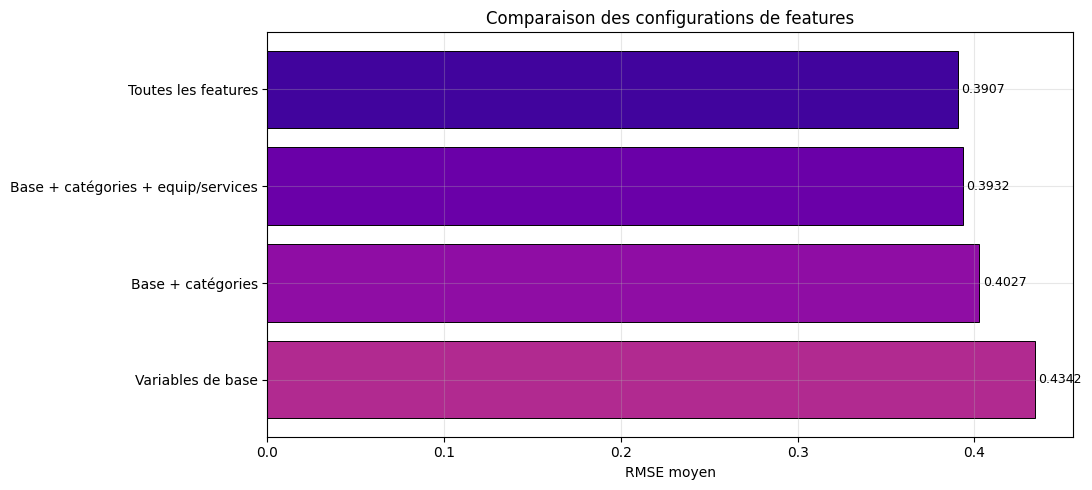

In [20]:
# Visualisation des configurations
import matplotlib.pyplot as plt
import numpy as np

fig, axe = plt.subplots(figsize=(11, 5))

paletteconfig = plt.cm.plasma(
    np.linspace(0.1, 0.4, len(resultatsconfigdf))
)

barres = axe.barh(
    resultatsconfigdf['configuration'],
    resultatsconfigdf['rmse_moyen'],
    color=paletteconfig,
    edgecolor='black',
    linewidth=0.7
)

axe.invert_yaxis()
axe.set_xlabel('RMSE moyen')
axe.set_title('Comparaison des configurations de features')
axe.grid(axis='x', alpha=0.3)

for barre, valeur in zip(barres, resultatsconfigdf['rmse_moyen']):
    axe.text(
        valeur + 0.002,
        barre.get_y() + barre.get_height() / 2,
        f'{valeur:.4f}',
        va='center',
        fontsize=9
    )

plt.tight_layout()
plt.show()

### Observations : comparaison des configurations de features

- **Variables de base** sont les moins performantes (RMSE ≈ 0.43) : elles ne suffisent pas à capturer toute la complexité du prix.

- **Base + catégories** améliore déjà le modèle (RMSE ≈ 0.40) : les informations de typologie apportent du signal utile.

- **Base + catégories + équipements/services** apporte un léger gain supplémentaire (RMSE ≈ 0.393) : les features ajoutées aident à mieux décrire le logement.

- **Toutes les features** donnent le meilleur résultat (RMSE ≈ 0.391) : même si le gain est faible, c’est la configuration la plus complète et la plus performante.

**Conclusion : on garde toutes les features avec LightGBM pour la suite.**

In [29]:
rows = []

# Résultats modèles (liste de dicts)
for r in resultatsmodeles:
    rows.append({
        'Expérience': r['modele'],
        'Type': 'Modèle',
        'RMSE (CV 3-fold)': round(r['rmse_moyen'], 4)
    })

# Résultats configurations (liste de dicts)
for r in resultatsconfig:
    rows.append({
        'Expérience': r['configuration'],
        'Type': 'Config features',
        'RMSE (CV 3-fold)': round(r['rmse_moyen'], 4)
    })

summary = pd.DataFrame(rows).sort_values('RMSE (CV 3-fold)').reset_index(drop=True)

print("=Resultats finaux")
print(summary.to_string(index=False))

=Resultats finaux
                        Expérience            Type  RMSE (CV 3-fold)
                          LightGBM          Modèle            0.3907
               Toutes les features Config features            0.3907
Base + catégories + equip/services Config features            0.3932
                 Gradient Boosting          Modèle            0.3977
                 Base + catégories Config features            0.4027
                       Extra Trees          Modèle            0.4076
                     Random Forest          Modèle            0.4085
                             Ridge          Modèle            0.4174
                 Variables de base Config features            0.4342
                               KNN          Modèle            0.4721


###  Conclusions des expériences

- **LightGBM** obtient le meilleur score parmi tous les modèles testés (RMSE ≈ 0.3907)

- Les modèles à base d’arbres (Gradient Boosting, Random Forest, Extra Trees) restent corrects mais moins performants que LightGBM

- Les modèles simples (Ridge, KNN) sont les moins adaptés à ce problème

- Côté features :
  - les **catégories encodées** apportent le plus gros gain
  - les **équipements/services** améliorent légèrement les performances
  - utiliser **toutes les features** donne le meilleur résultat global

 **Conclusion : LightGBM + toutes les features est la meilleure configuration (RMSE ≈ 0.3907)**




## 6.Choix de Light GBM

LightGBM est un algorithme de gradient boosting basé sur des arbres de décision.  
Chaque arbre corrige les erreurs des précédents, ce qui permet d’obtenir de très bonnes performances sur des données tabulaires comme les nôtres.

Il est également efficace sur les datasets avec beaucoup de variables et gère bien les interactions complexes.


### Validation croisée (5-fold)

On utilise une validation croisée en 5 parties :
- le modèle est entraîné 5 fois
- à chaque fois, 4 folds servent à l’entraînement et 1 fold au test
- cela permet d’obtenir une estimation fiable de la performance


### Paramètres principaux utilisés

| Paramètre | Valeur | Rôle |
|-----------|--------|------|
| learning_rate | 0.05 | Apprentissage progressif |
| num_leaves | 63 | Complexité des arbres |
| feature_fraction | 0.8 | Sous-échantillonnage des features |
| bagging_fraction | 0.8 | Sous-échantillonnage des données |

In [31]:
import numpy as np
import lightgbm as lgb
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error

kf = KFold(n_splits=5, shuffle=True, random_state=SEED)

oof_preds = np.zeros(len(X))
cv_scores = []

params = {
    'objective': 'regression',
    'metric': 'rmse',
    'learning_rate': 0.05,
    'num_leaves': 63,
    'max_depth': -1,
    'min_child_samples': 20,
    'feature_fraction': 0.8,
    'bagging_fraction': 0.8,
    'bagging_freq': 5,
    'reg_alpha': 0.1,
    'reg_lambda': 1.0,
    'random_state': SEED,
    'verbose': -1,
    'n_jobs': -1
}

best_iters = []

for fold, (tr_idx, val_idx) in enumerate(kf.split(X)):

    X_tr, X_val = X.iloc[tr_idx], X.iloc[val_idx]
    y_tr, y_val = y.iloc[tr_idx], y.iloc[val_idx]

    dtrain = lgb.Dataset(X_tr, label=y_tr)
    dval = lgb.Dataset(X_val, label=y_val)

    model = lgb.train(
        params,
        dtrain,
        num_boost_round=3000,
        valid_sets=[dval],
        callbacks=[
            lgb.early_stopping(150, verbose=False),
            lgb.log_evaluation(500)
        ]
    )

    preds = model.predict(X_val)
    oof_preds[val_idx] = preds

    rmse = np.sqrt(mean_squared_error(y_val, preds))
    cv_scores.append(rmse)
    best_iters.append(model.best_iteration)

    print(f"Fold {fold+1}/5 | RMSE={rmse:.4f} | best_iter={model.best_iteration}")

best_n = int(np.mean(best_iters) * 1.05)

print(f"CV RMSE : {np.mean(cv_scores):.4f} ± {np.std(cv_scores):.4f}")
print(f"Best number of iterations final : {best_n}")


Fold 1/5 | RMSE=0.3903 | best_iter=250
[500]	valid_0's rmse: 0.392334
Fold 2/5 | RMSE=0.3920 | best_iter=364
[500]	valid_0's rmse: 0.383989
Fold 3/5 | RMSE=0.3837 | best_iter=480
Fold 4/5 | RMSE=0.3675 | best_iter=297
[500]	valid_0's rmse: 0.39615
Fold 5/5 | RMSE=0.3955 | best_iter=416
CV RMSE : 0.3858 ± 0.0099
Best number of iterations final : 379


###  Résultats de la validation croisée

Le modèle LightGBM obtient un **RMSE moyen de 0.3858 ± 0.0099** sur les 5 folds.

Les performances sont **stables entre les folds**, ce qui indique que le modèle généralise bien et n’est pas en surapprentissage.

Les valeurs de `best_iteration` varient selon les folds, et la moyenne (~379) est utilisée pour construire le modèle final.

###  Interprétation

Un RMSE autour de **0.39 sur le log(price)** correspond à une erreur raisonnable sur ce type de données, qui restent très bruitées (prix Airbnb dépend fortement de facteurs non observés).


###  Conclusion

Le modèle est :
- performant
- stable
- prêt pour l’entraînement final sur l’ensemble des données

In [32]:
import lightgbm as lgb
import numpy as np

# Modèle final entraîné sur tout le train
print(f"Entraînement final ({best_n} itérations)...")

dtrain_full = lgb.Dataset(X, label=y)

final_model = lgb.train(
    params,
    dtrain_full,
    num_boost_round=best_n
)

test_preds = final_model.predict(X_test)

print(
    f"Prédictions test — "
    f"min={test_preds.min():.3f}  "
    f"max={test_preds.max():.3f}  "
    f"mean={test_preds.mean():.3f}"
)

Entraînement final (379 itérations)...
Prédictions test — min=2.629  max=7.659  mean=4.785


## 7. Analyse du modèle

Pour vérifier la qualité du modèle, on s’intéresse à trois points principaux :
- Les variables les plus influentes dans les prédictions
- La proximité entre les valeurs prédites et les valeurs réelles
- La répartition des erreurs pour vérifier s’il n’y a pas de biais ou de tendance particulière

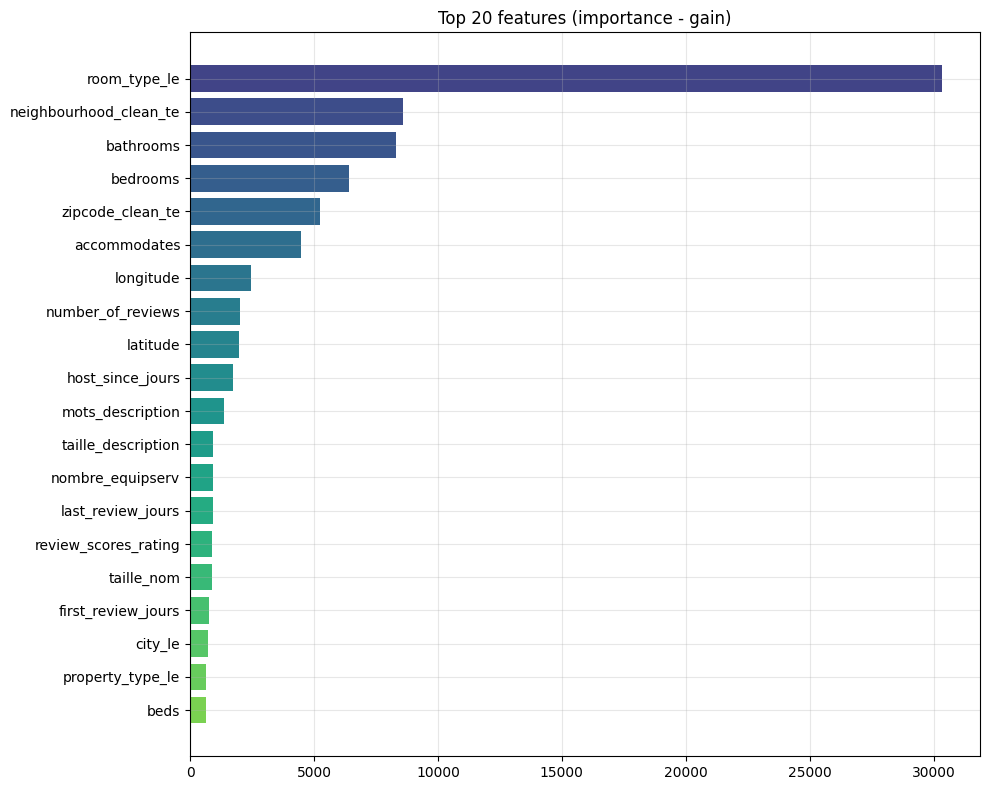

Top 10 features :
               feature   importance
          room_type_le 30357.013013
neighbourhood_clean_te  8582.479456
             bathrooms  8305.316327
              bedrooms  6392.467294
      zipcode_clean_te  5254.100064
          accommodates  4476.965152
             longitude  2467.642805
     number_of_reviews  2019.829404
              latitude  1953.455709
      host_since_jours  1716.992592


In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Feature importance
imp = pd.DataFrame({
    'feature': ALL_FEAT,
    'importance': final_model.feature_importance(importance_type='gain')
})

imp = imp.sort_values('importance', ascending=False).reset_index(drop=True)
top20 = imp.head(20)

fig, ax = plt.subplots(figsize=(10, 8))

colors = plt.cm.viridis(np.linspace(0.2, 0.8, len(top20)))

ax.barh(
    range(len(top20)),
    top20['importance'].values,
    color=colors
)

ax.set_yticks(range(len(top20)))
ax.set_yticklabels(top20['feature'].values, fontsize=10)

ax.invert_yaxis()
ax.set_title('Top 20 features (importance - gain)')

plt.tight_layout()
plt.show()

print("Top 10 features :")
print(imp.head(10).to_string(index=False))

### Ce que nous dit l'importance des features

### 📊 Ce que montre l’importance des variables

###  Ce que nous dit l’importance des features

- La variable la plus importante est **room_type_le**, ce qui montre que le type de logement influence fortement le prix.

- Ensuite, la **localisation** reste essentielle avec *neighbourhood_clean_te*, *zipcode_clean_te*, ainsi que *latitude* et *longitude* qui apparaissent toutes dans le top des variables.

- Les caractéristiques liées à la **taille du logement** (salles de bain, chambres, capacité d’accueil) ont aussi un impact important sur les prédictions.

- Le **nombre de reviews** et l’**ancienneté de l’hôte (host_since_jours)** jouent un rôle secondaire mais non négligeable.

Globalement, le modèle repose surtout sur le type de logement, la localisation et la taille du bien.

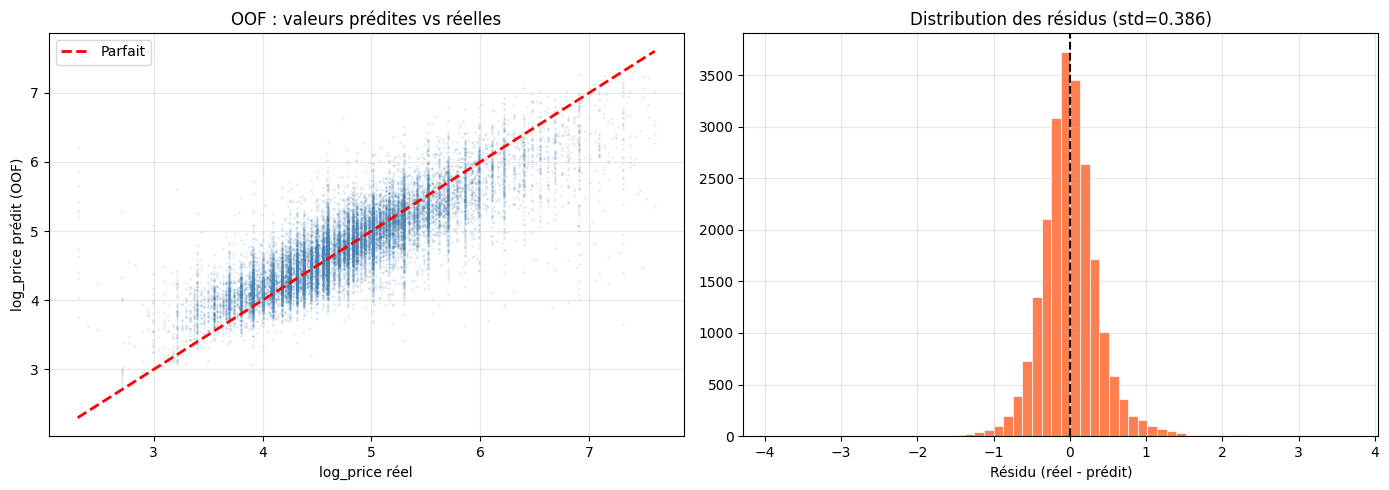

OOF RMSE global : 0.3859


In [34]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import mean_squared_error

# OOF : prédictions vs réel + distribution des résidus
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter réel vs prédit
axes[0].scatter(y, oof_preds, alpha=0.1, s=1, color='steelblue')
axes[0].plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2, label='Parfait')
axes[0].set_xlabel('log_price réel')
axes[0].set_ylabel('log_price prédit (OOF)')
axes[0].set_title('OOF : valeurs prédites vs réelles')
axes[0].legend()

# Résidus
residuals = y - oof_preds
axes[1].hist(residuals, bins=60, color='coral', edgecolor='white', linewidth=0.5)
axes[1].axvline(0, color='black', linestyle='--')
axes[1].set_title(f'Distribution des résidus (std={residuals.std():.3f})')
axes[1].set_xlabel('Résidu (réel - prédit)')

plt.tight_layout()
plt.show()

# RMSE OOF
oof_rmse = np.sqrt(mean_squared_error(y, oof_preds))
print(f"OOF RMSE global : {oof_rmse:.4f}")

###  Interprétation des résidus

- Les prédictions suivent globalement la diagonale, ce qui montre que le modèle est globalement fiable.

- Les résidus sont centrés autour de 0, ce qui indique qu’il n’y a pas de biais important (ni sur-estimation ni sous-estimation systématique).

- Le modèle est légèrement moins performant sur les valeurs extrêmes (prix très élevés ou très faibles), ce qui est attendu car ces cas sont moins fréquents dans les données.

## 8. Export des prédictions

Sauvegardé : predictions.csv (51,877 lignes)
           logpred
                  
14282777  4.937616
17029381  5.841705
7824740   5.033949
19811650  6.147093
12410741  4.637737
=== Vérification ===
Colonnes attendues : ['logpred']
Colonnes obtenues  : ['logpred']
Lignes             : 51,877

           logpred
14282777  4.937616
17029381  5.841705
7824740   5.033949
19811650  6.147093
12410741  4.637737


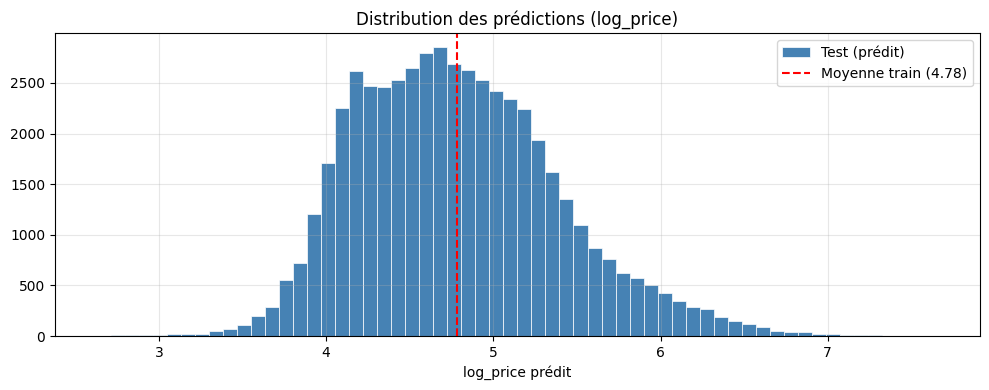

Export OK !


In [35]:
import pandas as pd
import matplotlib.pyplot as plt

# Création du fichier de submission
submission = pd.DataFrame(
    {'logpred': test_preds},
    index=test_enc['id'].values
)

submission.index.name = ''
submission.to_csv('predictions.csv')

print(f"Sauvegardé : predictions.csv ({len(submission):,} lignes)")
print(submission.head())


# Vérification du format
example = pd.read_csv('prediction_example.csv', index_col=0)
pred = pd.read_csv('predictions.csv', index_col=0)

print("=== Vérification ===")
print(f"Colonnes attendues : {list(example.columns)}")
print(f"Colonnes obtenues  : {list(pred.columns)}")
print(f"Lignes             : {len(pred):,}")
print()
print(pred.head(5))


# Distribution des prédictions
plt.figure(figsize=(10, 4))

plt.hist(
    pred['logpred'],
    bins=60,
    color='steelblue',
    edgecolor='white',
    linewidth=0.5,
    label='Test (prédit)'
)

plt.axvline(
    y.mean(),
    color='red',
    linestyle='--',
    label=f'Moyenne train ({y.mean():.2f})'
)

plt.title('Distribution des prédictions (log_price)')
plt.xlabel('log_price prédit')
plt.legend()

plt.tight_layout()
plt.show()

print("Export OK !")

## 9. Conclusion

###  Résultats obtenus

- Le modèle LightGBM atteint un **RMSE d’environ 0.39 sur le log(price)**, avec des performances stables sur validation croisée.
- Les variables les plus importantes sont principalement :
  - le **type de logement**
  - la **localisation (quartiers, code postal, coordonnées GPS)**
  - la **taille du bien (chambres, salles de bain, capacité)**



###  Points forts du projet

- L’encodage des variables catégorielles (quartiers, code postal) a fortement amélioré les performances.
- L’ajout des équipements et services a permis de mieux décrire les logements.
- La validation croisée a permis d’obtenir une estimation fiable et robuste des performances du modèle.



###  Améliorations possibles

- Exploiter davantage les descriptions textuelles des annonces (NLP).
- Tester des approches d’ensemble (stacking de modèles).
- Ajouter des données externes sur les quartiers (transports, attractivité, commerces).